In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import json
df = pd.read_parquet("../data/processed/bgl_parsed.parquet")
print(df.columns.tolist())

['label', 'timestamp', 'date', 'node', 'time', 'node_repeat', 'type', 'component', 'level', 'content', 'template_id', 'template', 'params']


In [5]:
sample = df[df["content"] == "instruction cache parity error corrected"].head(6)
print(sample[["time", "template_id", "template"]].to_string())

                        time  template_id                                  template
0 2005-06-03 15:42:50.363779            1  instruction cache parity error corrected
1 2005-06-03 15:42:50.527847            1  instruction cache parity error corrected
2 2005-06-03 15:42:50.675872            1  instruction cache parity error corrected
3 2005-06-03 15:42:50.823719            1  instruction cache parity error corrected
4 2005-06-03 15:42:50.982731            1  instruction cache parity error corrected
5 2005-06-03 15:42:51.131467            1  instruction cache parity error corrected


In [6]:
sample2 = df[df["content"].str.contains("integer alignment exceptions", na=False)].head(3)
print(sample2[["content", "template", "params"]].to_string())

                                                                                                                                                                                                                                                                                                                                                                                                               content                                                                                                                                                                                                                                                                                                                                                                                                       template                                                                                                                                                                                                   

Step 2: Template count

In [7]:
# Template count
n_templates = df["template_id"].nunique()
print(f"Total templates: {n_templates}")

Total templates: 1819


Step 3: Template frequency distribution

count    1.819000e+03
mean     2.591250e+03
std      4.328969e+04
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      5.000000e+00
max      1.706751e+06
Name: count, dtype: float64


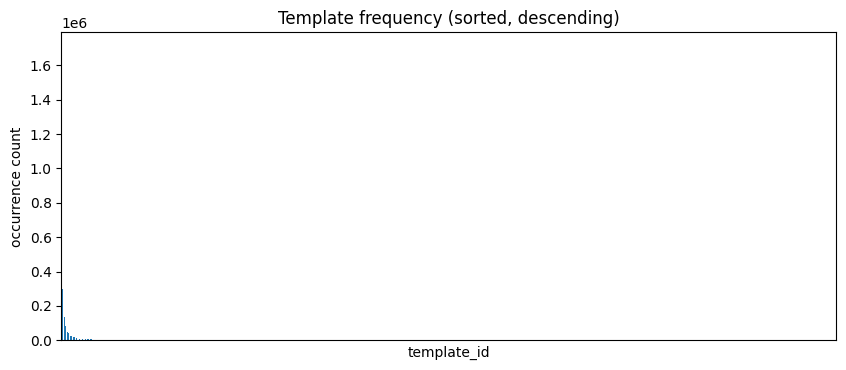

In [8]:
# Template frequency distribution
template_freq = df["template_id"].value_counts()

print(template_freq.describe())

plt.figure(figsize=(10,4))
template_freq.plot(kind="bar")  # too many bars to label individually — that's fine, shape is what matters
plt.title("Template frequency (sorted, descending)")
plt.ylabel("occurrence count")
plt.xticks([])
plt.show()

Step 4: Singleton-template ratio

In [9]:
# Singleton-template ratio
singleton_templates = (template_freq == 1).sum()
singleton_ratio = singleton_templates / n_templates

print(f"Singleton templates: {singleton_templates} / {n_templates} ({singleton_ratio:.2%})")

Singleton templates: 1161 / 1819 (63.83%)


Step 5: Template-to-label crosstab

In [10]:
# Template-to-label crosstab
# Which templates are most associated with real anomalies?
template_anomaly = df.groupby("template_id")["label"].apply(lambda x: (x != "-").mean())
top_anomaly_templates = template_anomaly.sort_values(ascending=False).head(15)

for tid, rate in top_anomaly_templates.items():
    example = df[df["template_id"] == tid]["template"].iloc[0]
    print(f"template_id={tid} | anomaly_rate={rate:.2%} | {example[:80]}")

template_id=572 | anomaly_rate=100.00% | kernel panic
template_id=1197 | anomaly_rate=100.00% | idoproxy communication failure: BGLERR_IDO_PKT_TIMEOUT connection lost to node/l
template_id=84 | anomaly_rate=100.00% | machine check interrupt (bit=0x06): L3 major internal error
template_id=17 | anomaly_rate=100.00% | ciod: failed to read message prefix on control stream (CioStream socket to 172.1
template_id=18 | anomaly_rate=100.00% | data TLB error interrupt
template_id=356 | anomaly_rate=100.00% | Power deactivated: R05-M0-N4
template_id=1203 | anomaly_rate=100.00% | machine check interrupt (bit=0x10): L2 dcache unit read return parity error
template_id=313 | anomaly_rate=100.00% | MailboxMonitor::serviceMailboxes() lib_ido_error: -1019 socket closed
template_id=1352 | anomaly_rate=100.00% | MidplaneSwitchController::clearPort() bll_clear_port failed: R63-M0-L0-U19-A
template_id=328 | anomaly_rate=100.00% | machine check interrupt (bit=0x09): Torus/Tree/GI read error 0
template_id=644

Step 6: Save findings

In [11]:
# Save findings
findings = {
    "n_templates": int(n_templates),
    "singleton_count": int(singleton_templates),
    "singleton_ratio": round(float(singleton_ratio), 4),
    "template_freq_median": float(template_freq.median()),
    "template_freq_max": int(template_freq.max()),
    "top_template_id": int(template_freq.idxmax()),
}

with open("../data/processed/eda_parsed_summary.json", "w") as f:
    json.dump(findings, f, indent=2)

print(findings)

{'n_templates': 1819, 'singleton_count': 1161, 'singleton_ratio': 0.6383, 'template_freq_median': 1.0, 'template_freq_max': 1706751, 'top_template_id': 3}


In [12]:
singleton_ids = template_freq[template_freq == 1].index
singleton_examples = df[df["template_id"].isin(singleton_ids)].drop_duplicates("template_id")

print(singleton_examples[["template"]].sample(20, random_state=42).to_string())

                                                            template
4001322                  4:090a5e00 5:09022c00 6:00083200 7:000020c9
4240913                   fpr5=0x1d510b54 c0252d92 dc69a17b 3fa38ba0
4157394              24:0915d5a8 25:002a0000 26:00000198 27:00000000
3366272                8:002349c0 9:00230000 10:00236000 11:00236a50
4670120                  fpr12=0x00000001 00000028 8c6eda20 3fea245a
221231               16:00364380 17:00440000 18:05fb0d70 19:05f6da60
4263423  r16=0x00000047 r17=0x00000085 r18=0x000000f9 r19=0x00ed4920
3681756              16:003b7740 17:003b7800 18:000000f3 19:00000010
4276247  r04=0x000c5fc8 r05=0x000c5fcc r06=0x0025c370 r07=0xb1140000
3503894              24:0feea5f7 25:00003950 26:002570b0 27:00000083
2686220              12:0fe9fa90 13:1eeeeeee 14:0fee0768 15:0fee0768
4157388              12:00014b2b 13:1eeeeeee 14:00225188 15:00dc4aa0
1395038                  4:14048d78 5:1416a548 6:140d9a08 7:14048ec8
4669905                  fpr10=0x6